# 03 · Embeddings y similitudes con el Tesauro de Salud
**Proyecto:** Salud en la esfera pública — análisis de tweets en español  
**Equivalente original:** `4_busqueda_ciencia.ipynb`

---

### Diferencias con el paper

| Aspecto | Paper (columnas de opinión) | Este notebook (tweets) |
|---|---|---|
| Unidad de análisis | Chunks de 150 palabras | Tweet completo (`Texto_limpio`) |
| Tesauro | UNESCO — Ciencia (17 subcategorías) | UNESCO — Salud (12 subcategorías) |
| Tesauro cargado desde | Archivos Excel por subcategoría en carpeta | Diccionario definido en este notebook |
| Similitud por documento | Promedio de similitudes de sus chunks | Directamente sobre el tweet |
| Modelo | `google/embeddinggemma-300M` (requiere HuggingFace login) | `paraphrase-multilingual-mpnet-base-v2` (público) |

**Entradas:**
- `resultadosPropios/corpus_cleaned.parquet`

**Salidas:**
- `resultadosPropios/tweet_embeddings.npy` — embeddings de cada tweet
- `resultadosPropios/similitudes_tweets.parquet` — scores por subcategoría
- `resultadosPropios/tweets_etiquetados_binario.parquet` — con columna `etiqueta_salud`
- `resultadosPropios/salud_tweets.parquet` — solo tweets con mención a salud


## 0 · Configuración

In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path
import os

DATA_PROCESSED = Path(r'C:\Users\afpue\OneDrive\Documentos\GitHub\icare\kMetodo\resultadosPropios')

# Modelo de embeddings
# El paper usa google/embeddinggemma-300M (requiere login en HuggingFace).
# Usamos paraphrase-multilingual-mpnet-base-v2: publico, ~278M params,
# excelente en similitud semantica en espanol, sin necesidad de login.
MODEL_ID   = 'paraphrase-multilingual-mpnet-base-v2'
BATCH_SIZE = 128
RELOAD     = False   # True para forzar recalculo de embeddings

# Umbral provisional (se optimiza en el notebook 04)
UMBRAL_PROVISIONAL = 0.47

print('[CONFIG] OK')
print(f'  DATA_PROCESSED : {DATA_PROCESSED.resolve()}')
print(f'  Modelo         : {MODEL_ID}')
print(f'  RELOAD         : {RELOAD}')


[CONFIG] OK
  DATA_PROCESSED : C:\Users\afpue\OneDrive\Documentos\GitHub\icare\kMetodo\resultadosPropios
  Modelo         : paraphrase-multilingual-mpnet-base-v2
  RELOAD         : False


## 1 · Imports y carga de datos

In [2]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# Equivalente a: chunks_df = pd.read_parquet(...) + corpus = pd.read_excel(...)
# Sin chunks: cargamos directamente corpus_cleaned.
# ============================================================
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo : {device}')

# Cargar corpus limpio (salida del notebook 01)
corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus['Fecha'] = pd.to_datetime(corpus['Fecha'], errors='coerce')

print(f'Tweets cargados : {len(corpus):,}')
print(f'Columnas        : {list(corpus.columns)}')
corpus.head(3)


Dispositivo : cuda
Tweets cargados : 151,424
Columnas        : ['id_doc', 'Author_Normalized', 'Author Name', 'Fecha', 'Date', 'anio', 'mes', 'anio_mes', 'Location', 'Number of Likes', 'Number of Retweets', 'Hashtags', 'Mentions', 'Sentimiento', 'Polaridad', 'Entidad', 'Content', 'Texto_limpio', 'n_palabras']


,id_doc,Author_Normalized,Author Name,Fecha,Date,anio,mes,anio_mes,Location,Number of Likes,Number of Retweets,Hashtags,Mentions,Sentimiento,Polaridad,Entidad,Content,Texto_limpio,n_palabras
0,1,@treporta,Telemetro Reporta,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,NaN,0.0,0.0,['#panama'],[],otro,Neutra,"Noticias locales, nacionales o globales",VÍDEO| Reos que no están contagiados con COVID...,VDEO Reos que no estn contagiados con COVID19 ...,15
1,2,@annytak21,ANNA KAROLYNNA,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,NaN,0.0,0.0,[],"['@ivanduque', '@jaimepumarejo']",otro,Negativa,Sin descripción,@IvanDuque @jaimepumarejo ya se enteraron de l...,ya se enteraron de la muerte supestamente por ...,24
2,3,@ferumapress,Fernando Umaña Mejía,2020-06-03,2020-06-03 18:56:17,2020,6,2020-06,NaN,0.0,0.0,[],"['@eltiempo', '@eltiempocali']",otro,Negativa,"Noticias locales, nacionales o globales",El calvario de una familia en Cali por su mamá...,El calvario de una familia en Cali por su mam ...,14


## 2 · Tesauro UNESCO — Salud
En el paper las subcategorías se cargan desde archivos Excel en una carpeta  
(`uss.cargar_subcategorias(dir_tesauro, model)`).  
Aquí definimos el tesauro directamente en el notebook para mayor transparencia.

Cada subcategoría se representa como una cadena de texto con sus términos  
clave — igual que hace `uss.cargar_subcategorias()` internamente.


In [3]:
# ============================================================
# CELL 2 — TESAURO UNESCO SALUD
# Equivalente a: subcat_embeddings = uss.cargar_subcategorias(dir_tesauro, model)
# ============================================================

TESAURO_SALUD = {
    'Salud_Economia_salud': (
        'economia de la salud financiamiento sanitario gasto en salud '
        'seguro medico seguridad social costos hospitalarios privatizacion '
        'presupuesto salud acceso medicamentos cobertura universal subsidio '
        'tarifa medica sistema salud reforma'
    ),
    'Salud_Estadisticas_sanitarias': (
        'estadisticas sanitarias datos epidemiologicos indicadores salud '
        'mortalidad morbilidad tasa incidencia prevalencia esperanza vida '
        'registros clinicos vigilancia epidemiologica encuestas salud '
        'datos demograficos cifras contagios fallecidos'
    ),
    'Salud_Higiene': (
        'higiene higiene personal saneamiento basico lavado manos '
        'desinfeccion esterilizacion agua potable higiene alimentaria '
        'higiene publica salubridad condiciones sanitarias prevencion '
        'limpieza aseo tapabocas mascarilla distanciamiento'
    ),
    'Salud_Control_alimentos': (
        'control alimentos inocuidad alimentaria seguridad alimentaria '
        'inspeccion alimentos contaminacion alimentos etiquetado nutricional '
        'regulacion alimentaria INVIMA alimentos ultraprocesados '
        'calidad nutricional cadena alimentaria aditivos'
    ),
    'Salud_Epidemiologia': (
        'epidemiologia brote epidemico pandemia epidemia endemia '
        'transmision enfermedades contagio infeccion vectores '
        'cadena transmision R0 tasa contagio cuarentena '
        'aislamiento preventivo trazabilidad contacto estrecho '
        'covid coronavirus positivo caso confirmado'
    ),
    'Salud_Higiene_ambiental': (
        'higiene ambiental contaminacion ambiental calidad aire '
        'residuos solidos gestion residuos contaminacion agua '
        'ruido ambiental exposicion quimicos salud ambiental '
        'ecosistemas salud plaguicidas metales pesados'
    ),
    'Salud_Lucha_enfermedades': (
        'lucha enfermedades control enfermedades vacunacion vacuna '
        'inmunizacion erradicacion enfermedades tratamiento medico '
        'diagnostico temprano deteccion oportuna campana salud '
        'programa salud publica resistencia antimicrobiana antibioticos '
        'medicamento farmaco dosis'
    ),
    'Salud_Politica_drogas': (
        'politica drogas regulacion medicamentos medicamentos genericos '
        'acceso medicamentos precios medicamentos ensayos clinicos '
        'aprobacion farmacos farmacovigilancia patentes farmaceuticas '
        'automedicacion uso racional medicamentos'
    ),
    'Salud_Toxicomania': (
        'toxicomania adiccion consumo drogas sustancias psicoactivas '
        'dependencia rehabilitacion desintoxicacion alcoholismo '
        'drogadiccion prevencion consumo drogas tratamiento adicciones '
        'reduccion danos alcohol tabaco'
    ),
    'Salud_Salud_mujer': (
        'salud mujer salud femenina derechos reproductivos '
        'salud sexual reproductiva anticoncepcion planificacion familiar '
        'cancer mama cancer cuello uterino violencia obstetrica '
        'lactancia materna menstruacion menopausia embarazo'
    ),
    'Salud_Materno_infantil': (
        'salud materno infantil salud materna mortalidad materna '
        'atencion prenatal parto neonatal lactancia mortalidad infantil '
        'vacunas infantiles nutricion infantil desarrollo infantil '
        'pediatria crecimiento bebe recien nacido'
    ),
    'Salud_Mental': (
        'salud mental bienestar mental trastorno mental depresion '
        'ansiedad estres burnout suicidio prevencion suicidio '
        'psicologia clinica psiquiatria terapia psicologica '
        'enfermedad mental psicosis esquizofrenia trastorno bipolar '
        'cuarentena aislamiento soledad'
    ),
}

SUBCAT_NOMBRES = list(TESAURO_SALUD.keys())
SUBCAT_TEXTOS  = list(TESAURO_SALUD.values())

print(f'Subcategorias del Tesauro de Salud: {len(TESAURO_SALUD)}')
for k in SUBCAT_NOMBRES:
    print(f'  · {k}')


Subcategorias del Tesauro de Salud: 12
  · Salud_Economia_salud
  · Salud_Estadisticas_sanitarias
  · Salud_Higiene
  · Salud_Control_alimentos
  · Salud_Epidemiologia
  · Salud_Higiene_ambiental
  · Salud_Lucha_enfermedades
  · Salud_Politica_drogas
  · Salud_Toxicomania
  · Salud_Salud_mujer
  · Salud_Materno_infantil
  · Salud_Mental


## 3 · Cargar modelo de embeddings
En el paper se usa `google/embeddinggemma-300M` con login de HuggingFace.  
Usamos `paraphrase-multilingual-mpnet-base-v2`: mismo rango de parámetros,  
público, sin login, y top en benchmarks de similitud semántica en español.


In [4]:
# ============================================================
# CELL 3 — CARGAR MODELO
# Equivalente a:
#   login()
#   model = SentenceTransformer('google/embeddinggemma-300M').to(device)
# ============================================================

model = SentenceTransformer(MODEL_ID, device=device)

print(f'Modelo          : {MODEL_ID}')
print(f'Dispositivo     : {device}')
print(f'Max seq length  : {model.max_seq_length}')
print(f'Dimension emb   : {model.get_sentence_embedding_dimension()}')
n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros      : {n_params/1e6:.0f}M')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo          : paraphrase-multilingual-mpnet-base-v2
Dispositivo     : cuda
Max seq length  : 128
Dimension emb   : 768
Parametros      : 278M


## 4 · Embeddings de las subcategorías del Tesauro
Cada subcategoría se convierte en un vector — el punto de comparación  
para medir qué tan cerca está cada tweet del concepto de salud.


In [5]:
# ============================================================
# CELL 4 — EMBEDDINGS TESAURO
# Equivalente a: subcat_embeddings = uss.cargar_subcategorias(...)
# ============================================================

print('Codificando subcategorias del Tesauro...')
subcat_embeddings = model.encode(
    SUBCAT_TEXTOS,
    batch_size=len(SUBCAT_TEXTOS),
    show_progress_bar=False,
    normalize_embeddings=True,
)
print(f'Shape embeddings Tesauro : {subcat_embeddings.shape}  '
      f'({len(SUBCAT_NOMBRES)} subcategorias x {subcat_embeddings.shape[1]} dims)')


Codificando subcategorias del Tesauro...
Shape embeddings Tesauro : (12, 768)  (12 subcategorias x 768 dims)


## 5 · Embeddings de los tweets
En el paper: `uss.obtener_embeddings_chunks(chunks_df, model, save_path=...)`  
Replicamos la misma función con caché en disco (`RELOAD=False` no recalcula  
si el archivo ya existe).


In [6]:
# ============================================================
# CELL 5 — EMBEDDINGS DE TWEETS
# Equivalente a: chunk_embeddings = uss.obtener_embeddings_chunks(...)
# Sin chunks: codificamos Texto_limpio directamente.
# ============================================================

SAVE_PATH_EMB = DATA_PROCESSED / 'tweet_embeddings.npy'

def obtener_embeddings_tweets(
    corpus,
    model,
    col_texto: str = 'Texto_limpio',
    batch_size: int = 128,
    save_path: Path = SAVE_PATH_EMB,
    RELOAD: bool = False,
) -> np.ndarray:
    """
    Replica de uss.obtener_embeddings_chunks() del paper.
    Calcula o carga embeddings de los tweets segun RELOAD.
    """
    if not RELOAD and save_path.exists():
        print(f'Embeddings encontrados en {save_path}, cargando...')
        embeddings = np.load(save_path)
        print(f'Embeddings cargados — shape: {embeddings.shape}')
        return embeddings

    print('Calculando embeddings desde cero...')
    textos = corpus[col_texto].fillna('').tolist()
    embeddings = model.encode(
        textos,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,   # L2-norm: coseno = producto punto
        device=device,
    )
    np.save(save_path, embeddings)
    print(f'Embeddings calculados y guardados — shape: {embeddings.shape}')
    return embeddings


tweet_embeddings = obtener_embeddings_tweets(
    corpus,
    model,
    batch_size=BATCH_SIZE,
    RELOAD=RELOAD,
)


Calculando embeddings desde cero...


Batches:   0%|          | 0/1183 [00:00<?, ?it/s]

Embeddings calculados y guardados — shape: (151424, 768)


## 6 · Matriz de similitud coseno S ∈ R^(m × n)
Calculamos la similitud entre cada tweet y cada subcategoría del Tesauro.  
Como los embeddings están L2-normalizados, coseno = producto punto.

Equivalente a `uss.calcular_similitudes_chunks()` del paper.


In [7]:
# ============================================================
# CELL 6 — MATRIZ DE SIMILITUD COSENO
# Equivalente a: sim_df = uss.calcular_similitudes_chunks(...)
# ============================================================

print('Calculando matriz de similitud coseno S...')

# (m_tweets x dim) @ (dim x n_subcats) = (m_tweets x n_subcats)
# Como embeddings estan normalizados: coseno = producto punto
S = cosine_similarity(tweet_embeddings, subcat_embeddings)

print(f'Matriz S : {S.shape}  ({S.shape[0]:,} tweets x {S.shape[1]} subcategorias)')
print(f'Similitud maxima global : {S.max():.4f}')
print(f'Similitud media global  : {S.mean():.4f}')

# Construir DataFrame de similitudes (igual que sim_df del paper)
sim_df = pd.DataFrame(S, columns=SUBCAT_NOMBRES)
sim_df.insert(0, 'id_doc',   corpus['id_doc'].values)
sim_df.insert(1, 'autor',    corpus['Author_Normalized'].values)
sim_df.insert(2, 'fecha',    corpus['Fecha'].values)

sim_df.head(3)


Calculando matriz de similitud coseno S...
Matriz S : (151424, 12)  (151,424 tweets x 12 subcategorias)
Similitud maxima global : 0.8063
Similitud media global  : 0.1872


,id_doc,autor,fecha,Salud_Economia_salud,Salud_Estadisticas_sanitarias,Salud_Higiene,Salud_Control_alimentos,Salud_Epidemiologia,Salud_Higiene_ambiental,Salud_Lucha_enfermedades,Salud_Politica_drogas,Salud_Toxicomania,Salud_Salud_mujer,Salud_Materno_infantil,Salud_Mental
0,1,@treporta,2020-06-03,0.108315,0.207589,0.228836,0.148676,0.420019,0.175693,0.283072,0.078428,0.093693,0.158637,0.229696,0.011602
1,2,@annytak21,2020-06-03,0.081781,0.245268,0.145530,0.026931,0.219293,0.101776,0.178353,0.073949,0.133602,0.249742,0.226577,0.128509
2,3,@ferumapress,2020-06-03,0.194415,0.254547,0.134160,0.082347,0.219495,0.109057,0.162065,0.146850,0.159413,0.369606,0.306537,0.247940


## 7 · Distribución de similitudes
Exploramos la distribución del score máximo por tweet para orientar  
la elección del umbral τ (se optimizará en el notebook 04).


Distribucion de score_max (mejor subcategoria por tweet):
  P 10: 0.1990
  P 25: 0.2483
  P 50: 0.3263
  P 75: 0.4223
  P 90: 0.5120
  P 95: 0.5657
  P 99: 0.6628


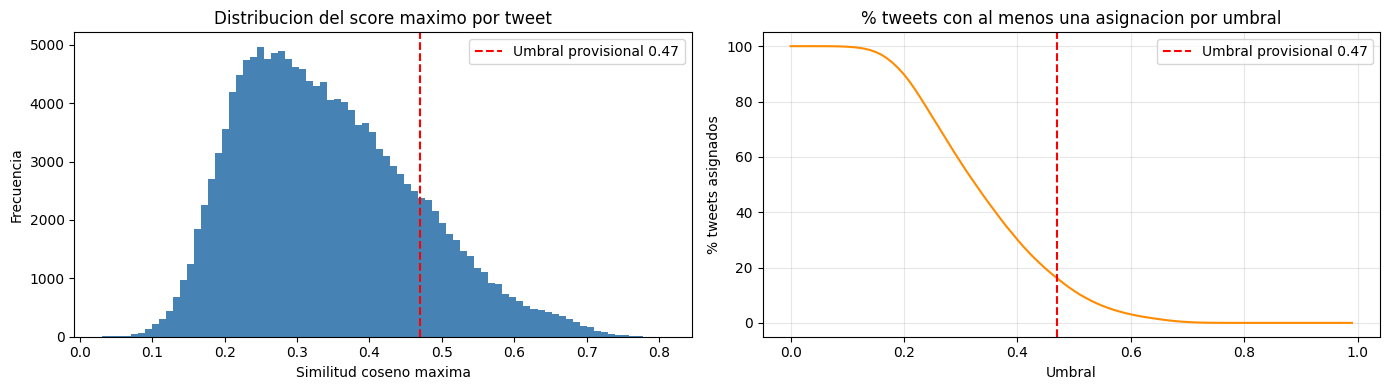

In [8]:
# ============================================================
# CELL 7 — DISTRIBUCION DE SIMILITUDES
# Equivalente a las graficas de umbral del paper (celdas 29-31)
# ============================================================

subcat_cols = SUBCAT_NOMBRES
sim_temp    = sim_df[subcat_cols].astype(float)

# Score maximo por tweet (mejor subcategoria)
sim_df['score_max']    = sim_temp.max(axis=1)
sim_df['subcat_max']   = sim_temp.idxmax(axis=1)

# Percentiles orientativos
print('Distribucion de score_max (mejor subcategoria por tweet):')
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f'  P{int(q*100):3d}: {sim_df["score_max"].quantile(q):.4f}')

# Grafica 1: histograma de score_max
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sim_df['score_max'], bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(UMBRAL_PROVISIONAL, color='red', linestyle='--',
                label=f'Umbral provisional {UMBRAL_PROVISIONAL}')
axes[0].set_title('Distribucion del score maximo por tweet')
axes[0].set_xlabel('Similitud coseno maxima')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Grafica 2: % tweets asignados por umbral
umbrales = np.arange(0, 1, 0.01)
pct_asignados = [
    (sim_temp.max(axis=1) >= u).mean() * 100
    for u in umbrales
]
axes[1].plot(umbrales, pct_asignados, color='darkorange')
axes[1].axvline(UMBRAL_PROVISIONAL, color='red', linestyle='--',
                label=f'Umbral provisional {UMBRAL_PROVISIONAL}')
axes[1].set_title('% tweets con al menos una asignacion por umbral')
axes[1].set_xlabel('Umbral')
axes[1].set_ylabel('% tweets asignados')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_distribucion_similitudes.png', dpi=150)
plt.show()


## 8 · Estadísticos por subcategoría
Equivalente a `descriptivos = sim_temp.describe()` del paper.

In [9]:
# ============================================================
# CELL 8 — ESTADISTICOS POR SUBCATEGORIA
# Equivalente a: descriptivos.T del paper (celda 33)
# ============================================================

descriptivos = sim_df[subcat_cols].describe().T
descriptivos = descriptivos.round(4)
print(descriptivos.to_string())
descriptivos


                                  count    mean     std     min     25%     50%     75%     max
Salud_Economia_salud           151424.0  0.1621  0.0944 -0.1265  0.0949  0.1525  0.2192  0.7093
Salud_Estadisticas_sanitarias  151424.0  0.2377  0.1092 -0.1402  0.1551  0.2335  0.3159  0.7210
Salud_Higiene                  151424.0  0.1977  0.0989 -0.1620  0.1302  0.1873  0.2543  0.8063
Salud_Control_alimentos        151424.0  0.1359  0.0837 -0.2148  0.0788  0.1285  0.1850  0.6873
Salud_Epidemiologia            151424.0  0.2865  0.1377 -0.0987  0.1849  0.2604  0.3711  0.7841
Salud_Higiene_ambiental        151424.0  0.1743  0.0856 -0.1376  0.1157  0.1663  0.2238  0.7132
Salud_Lucha_enfermedades       151424.0  0.2411  0.1133 -0.1031  0.1532  0.2291  0.3188  0.6545
Salud_Politica_drogas          151424.0  0.1569  0.0891 -0.1477  0.0939  0.1481  0.2112  0.6562
Salud_Toxicomania              151424.0  0.1422  0.0651 -0.1186  0.1006  0.1416  0.1826  0.7514
Salud_Salud_mujer              151424.0 

,count,mean,std,min,25%,50%,75%,max
Salud_Economia_salud,151424.0,0.1621,0.0944,-0.1265,0.0949,0.1525,0.2192,0.7093
Salud_Estadisticas_sanitarias,151424.0,0.2377,0.1092,-0.1402,0.1551,0.2335,0.3159,0.7210
Salud_Higiene,151424.0,0.1977,0.0989,-0.1620,0.1302,0.1873,0.2543,0.8063
Salud_Control_alimentos,151424.0,0.1359,0.0837,-0.2148,0.0788,0.1285,0.1850,0.6873
Salud_Epidemiologia,151424.0,0.2865,0.1377,-0.0987,0.1849,0.2604,0.3711,0.7841
Salud_Higiene_ambiental,151424.0,0.1743,0.0856,-0.1376,0.1157,0.1663,0.2238,0.7132
Salud_Lucha_enfermedades,151424.0,0.2411,0.1133,-0.1031,0.1532,0.2291,0.3188,0.6545
Salud_Politica_drogas,151424.0,0.1569,0.0891,-0.1477,0.0939,0.1481,0.2112,0.6562
Salud_Toxicomania,151424.0,0.1422,0.0651,-0.1186,0.1006,0.1416,0.1826,0.7514
Salud_Salud_mujer,151424.0,0.1896,0.0762,-0.1173,0.1386,0.1876,0.2382,0.6810


## 9 · Asignación provisional con umbral τ
Usamos el umbral provisional `0.47` (mismo punto de partida que el paper).  
El umbral óptimo se calibra en el **notebook 04** mediante validación manual.


In [10]:
# ============================================================
# CELL 9 — ASIGNACION CON UMBRAL PROVISIONAL
# Equivalente a: resultado = uss.asignar_categorias(sim_df, umbral=0.47)
# ============================================================

def asignar_categorias(sim_df, subcat_cols, umbral=0.47):
    """
    Replica de uss.asignar_categorias() del paper.
    Para cada tweet asigna la subcategoria con mayor similitud
    si supera el umbral; si no, asigna 'ninguna'.
    """
    resultado = sim_df.copy()
    scores    = resultado[subcat_cols].astype(float)

    resultado['score_max']  = scores.max(axis=1)
    resultado['subcat_max'] = scores.idxmax(axis=1)

    # Etiqueta binaria: 1 si supera el umbral, 0 si no
    resultado['etiqueta_salud'] = (resultado['score_max'] >= umbral).astype(int)

    # Categoria asignada (o 'ninguna')
    resultado['categoria_detectada'] = resultado.apply(
        lambda r: r['subcat_max'] if r['etiqueta_salud'] == 1 else 'ninguna',
        axis=1
    )
    return resultado


resultado = asignar_categorias(sim_df, subcat_cols, umbral=UMBRAL_PROVISIONAL)

n_salud = resultado['etiqueta_salud'].sum()
pct     = n_salud / len(resultado) * 100
print(f'Tweets con mencion de salud (tau={UMBRAL_PROVISIONAL}): {n_salud:,} ({pct:.1f}%)')
print()
print('Distribucion por subcategoria:')
print(resultado[resultado['etiqueta_salud']==1]['categoria_detectada']
      .value_counts().to_string())


Tweets con mencion de salud (tau=0.47): 24,460 (16.2%)

Distribucion por subcategoria:
categoria_detectada
Salud_Epidemiologia              16148
Salud_Lucha_enfermedades          3358
Salud_Higiene                     1741
Salud_Estadisticas_sanitarias     1593
Salud_Economia_salud               473
Salud_Politica_drogas              262
Salud_Higiene_ambiental            231
Salud_Materno_infantil             222
Salud_Salud_mujer                  213
Salud_Control_alimentos            111
Salud_Mental                        63
Salud_Toxicomania                   45


## 10 · Guardar resultados

In [11]:
# ============================================================
# CELL 10 — GUARDAR RESULTADOS
# Equivalente a:
#   sim_df.to_excel('similitudes_chunks.xlsx')
#   resultado.to_excel('chunks_etiquetados_binario.xlsx')
#   resultado_ciencia.to_excel('ciencia_chunks.xlsx')
# ============================================================

# 1. Similitudes por tweet (todas las subcategorias)
sim_df.to_parquet(DATA_PROCESSED / 'similitudes_tweets.parquet', index=False)
print('[GUARDADO] similitudes_tweets.parquet')

# 2. Tweets etiquetados (binario + categoria)
resultado.to_parquet(DATA_PROCESSED / 'tweets_etiquetados_binario.parquet', index=False)
print('[GUARDADO] tweets_etiquetados_binario.parquet')

# 3. Solo tweets con mencion de salud
salud_tweets = resultado[resultado['etiqueta_salud'] == 1].copy()
salud_tweets.to_parquet(DATA_PROCESSED / 'salud_tweets.parquet', index=False)
print('[GUARDADO] salud_tweets.parquet')

# 4. Excel de similitudes para inspeccion manual (util para el notebook 04)
cols_guardar = ['id_doc', 'autor', 'fecha'] + subcat_cols + ['score_max', 'subcat_max']
sim_df[cols_guardar].to_excel(
    DATA_PROCESSED / 'similitudes_tweets.xlsx', index=False, engine='openpyxl'
)
print('[GUARDADO] similitudes_tweets.xlsx')

print()
print(f'  Total tweets            : {len(resultado):,}')
print(f'  Tweets con salud        : {len(salud_tweets):,} ({len(salud_tweets)/len(resultado)*100:.1f}%)')
print(f'  Umbral usado (prov.)    : {UMBRAL_PROVISIONAL}')
print()
print('Notebook 03 completado.')
print('Siguiente -> 04_seleccion_umbral.ipynb')


[GUARDADO] similitudes_tweets.parquet
[GUARDADO] tweets_etiquetados_binario.parquet
[GUARDADO] salud_tweets.parquet
[GUARDADO] similitudes_tweets.xlsx

  Total tweets            : 151,424
  Tweets con salud        : 24,460 (16.2%)
  Umbral usado (prov.)    : 0.47

Notebook 03 completado.
Siguiente -> 04_seleccion_umbral.ipynb
